1. Raw data
2. Train / Val / Test
3. Scaling (fit on train only via Pipeline)
4. Predictions as numbers
5. Train vs Val loss curve over epochs (SGDRegressor, so you can see learning)
6. Regularization (Ridge / Lasso / ElasticNet)
7. Final test prediction


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    SGDRegressor,
    HuberRegressor
)
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

pd.set_option("display.precision", 4)

In [16]:
data = pd.DataFrame({
    "x1_size": [1, 2, 3, 4, 5, 6, 7],
    "x2_bedrooms": [1, 1, 2, 2, 3, 3, 4],
    "price_y": [1.0, 1.3, 1.6, 1.9, 2.1, 2.2, 2.5]
})

data


,x1_size,x2_bedrooms,price_y
0,1,1,1.0
1,2,1,1.3
2,3,2,1.6
3,4,2,1.9
4,5,3,2.1
5,6,3,2.2
6,7,4,2.5


In [17]:
train = data.iloc[:5].copy()
val   = data.iloc[5:6].copy()
test  = data.iloc[6:].copy()

print("TRAIN")
display(train)

print("VALIDATION")
display(val)

print("TEST")
display(test)



TRAIN


,x1_size,x2_bedrooms,price_y
0,1,1,1.0
1,2,1,1.3
2,3,2,1.6
3,4,2,1.9
4,5,3,2.1


VALIDATION


,x1_size,x2_bedrooms,price_y
5,6,3,2.2


TEST


,x1_size,x2_bedrooms,price_y
6,7,4,2.5


**Prepare matrices**

In [18]:
X_train = train[["x1_size", "x2_bedrooms"]].values
y_train = train["price_y"].values

X_val = val[["x1_size", "x2_bedrooms"]].values
y_val = val["price_y"].values

X_test = test[["x1_size", "x2_bedrooms"]].values
y_test = test["price_y"].values



Adjusted R²

In [19]:
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


Evaluate model (ALL METRICS)

In [20]:
def evaluate_model(name, model, scaler):
    Xtr_s = scaler.transform(X_train)
    Xv_s  = scaler.transform(X_val)
    Xt_s  = scaler.transform(X_test)

    ytr_p = model.predict(Xtr_s)
    yv_p  = model.predict(Xv_s)
    yt_p  = model.predict(Xt_s)

    return {
        "Model": name,
        "Train MSE": mean_squared_error(y_train, ytr_p),
        "Val MSE": mean_squared_error(y_val, yv_p),
        "Test MSE": mean_squared_error(y_test, yt_p),
        "Train R²": r2_score(y_train, ytr_p),
        "Adj Train R²": adjusted_r2(
            r2_score(y_train, ytr_p),
            len(y_train),
            X_train.shape[1]
        ),
        "Test Prediction": float(yt_p[0])
    }

Closed-form models (most common ML usage)

— Train all regression models

In [8]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge (α=0.1)": Ridge(alpha=0.1),
    "Ridge (α=1.0)": Ridge(alpha=1.0),
    "Lasso (α=0.05)": Lasso(alpha=0.05, max_iter=10000),
    "ElasticNet (α=0.05, l1=0.5)": ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000),
    "HuberRegressor": HuberRegressor()
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)

    results.append(
        evaluate_model(name, pipe.named_steps["model"], pipe.named_steps["scaler"])
    )

results_df = pd.DataFrame(results)
results_df.sort_values("Val MSE")

,Model,Train MSE,Val MSE,Test MSE,Train R²,Adj Train R²,Test Prediction
2,Ridge (α=1.0),0.0060,0.0051,0.0105,0.9622,0.9244,2.6025
3,Lasso (α=0.05),0.0033,0.0130,0.0034,0.9791,0.9581,2.5586
4,"ElasticNet (α=0.05, l1=0.5)",0.0021,0.0207,0.0116,0.9868,0.9736,2.6077
1,Ridge (α=0.1),0.0010,0.0394,0.0333,0.9935,0.9870,2.6824
5,HuberRegressor,0.0005,0.0576,0.0339,0.9966,0.9932,2.6842
0,LinearRegression,0.0005,0.0576,0.0348,0.9966,0.9932,2.6867


Iterative ML model (SGDRegressor)
 — Train SGDRegressor (shows learning like gradient descent)

In [9]:
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xv_s  = scaler.transform(X_val)
Xt_s  = scaler.transform(X_test)

sgd = SGDRegressor(
    loss="squared_error",
    penalty="elasticnet",
    alpha=0.0005,
    l1_ratio=0.0,     # L2
    learning_rate="constant",
    eta0=0.05,
    max_iter=1,
    tol=None,
    warm_start=True,
    random_state=42
)

train_curve = []
val_curve = []

for epoch in range(300):
    sgd.partial_fit(Xtr_s, y_train)

    train_curve.append(
        mean_squared_error(y_train, sgd.predict(Xtr_s))
    )
    val_curve.append(
        mean_squared_error(y_val, sgd.predict(Xv_s))
    )



Plot loss curves (Train vs Val)

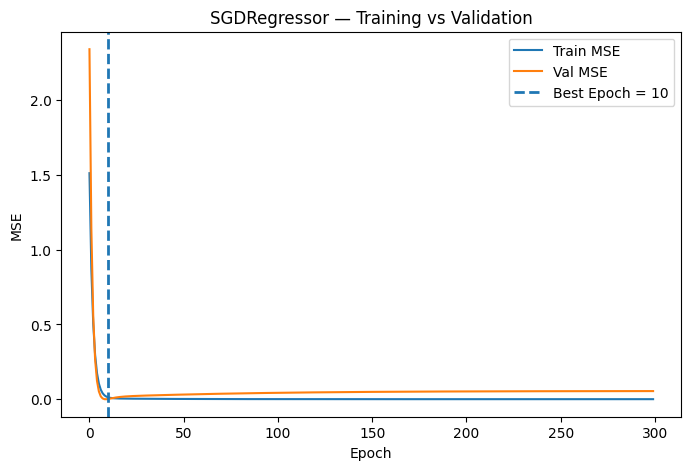

In [21]:
best_epoch = int(np.argmin(val_curve)) + 1

plt.figure(figsize=(8,5))
plt.plot(train_curve, label="Train MSE")
plt.plot(val_curve, label="Val MSE")

plt.axvline(best_epoch, linestyle="--", linewidth=2,
            label=f"Best Epoch = {best_epoch}")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("SGDRegressor — Training vs Validation")
plt.legend()
plt.show()



SGD final metrics

In [22]:
sgd_metrics = {
    "Model": "SGDRegressor (L2)",
    "Train MSE": mean_squared_error(y_train, sgd.predict(Xtr_s)),
    "Val MSE": mean_squared_error(y_val, sgd.predict(Xv_s)),
    "Test MSE": mean_squared_error(y_test, sgd.predict(Xt_s)),
    "Train R²": r2_score(y_train, sgd.predict(Xtr_s)),
    "Adj Train R²": adjusted_r2(
        r2_score(y_train, sgd.predict(Xtr_s)),
        len(y_train),
        X_train.shape[1]
    ),
    "Test Prediction": float(sgd.predict(Xt_s)[0])
}

pd.DataFrame([sgd_metrics])


,Model,Train MSE,Val MSE,Test MSE,Train R²,Adj Train R²,Test Prediction
0,SGDRegressor (L2),0.0005,0.0546,0.0324,0.9966,0.9931,2.68


Statistical significance (p-values). p-values require larger datasets — this is for understanding, not inference.

Statsmodels (p-values + confidence)

In [12]:
X_sm = sm.add_constant(X_train)
y_sm = y_train

sm_model = sm.OLS(y_sm, X_sm).fit()
sm_model.summary()


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     294.5
Date:                Sun, 08 Feb 2026   Prob (F-statistic):            0.00338
Time:                        09:27:55   Log-Likelihood:                 11.746
No. Observations:                   5   AIC:                            -17.49
Df Residuals:                       2   BIC:                            -18.66
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7600      0.043     17.591      0.003       0.574       0.946
x1             0.3133      0.035      8.882      0.012       0.162       0.465
x2            -0.0667      0.067     -1.000      0.423      -0.354       0.220
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.017
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.570
Skew:                           0.289   Prob(JB):                        0.752
Kurtosis:                       1.450   Cond. No.                         18.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Clean coefficient table

In [23]:
coef_table = pd.DataFrame({
    "Coefficient": sm_model.params,
    "Std Error": sm_model.bse,
    "p-value": sm_model.pvalues
})

coef_table


,Coefficient,Std Error,p-value
0,0.7600,0.0432,0.0032
1,0.3133,0.0353,0.0124
2,-0.0667,0.0667,0.4226


FINAL DASHBOARD (ONE SCREEN)


 — All models compared

In [24]:
final_dashboard = pd.concat(
    [results_df, pd.DataFrame([sgd_metrics])],
    ignore_index=True
)

final_dashboard.sort_values("Val MSE")

,Model,Train MSE,Val MSE,Test MSE,Train R²,Adj Train R²,Test Prediction
2,Ridge (α=1.0),0.0060,0.0051,0.0105,0.9622,0.9244,2.6025
3,Lasso (α=0.05),0.0033,0.0130,0.0034,0.9791,0.9581,2.5586
4,"ElasticNet (α=0.05, l1=0.5)",0.0021,0.0207,0.0116,0.9868,0.9736,2.6077
1,Ridge (α=0.1),0.0010,0.0394,0.0333,0.9935,0.9870,2.6824
6,SGDRegressor (L2),0.0005,0.0546,0.0324,0.9966,0.9931,2.6800
5,HuberRegressor,0.0005,0.0576,0.0339,0.9966,0.9932,2.6842
0,LinearRegression,0.0005,0.0576,0.0348,0.9966,0.9932,2.6867
